In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from _fractures import *

In [2]:
xmin,ymin,zmin,xmax,ymax,zmax,Nx,Ny,Nz,dx,dy,dz = get_grid_parameters()
dx

0.4

In [49]:
##IMPORT DATA AS A CSV FILE

data = pd.read_csv("energies_quantum_ricker_IC_1_6x6x6_-1to1_0.0002_0.001")
#Define whether just classical values will be plotted
quantum = True

In [50]:
#View data
data

,total_quantum,total_classical,kinetic_quantum,kinetic_classical,potential_quantum,potential_classical,time,Layer #
0,0.514434,0.514479,0.182340,0.182373,0.332094,0.332105,0.0002,1
1,2.058604,2.058615,0.708938,0.708926,1.349666,1.349690,0.0002,2
2,6.950975,6.950569,3.720877,3.720594,3.230098,3.229975,0.0002,3
3,6.504404,6.504147,3.753620,3.753475,2.750784,2.750672,0.0002,4
4,1.406562,1.406630,0.414562,0.414588,0.992000,0.992042,0.0002,5
5,2.380325,2.382220,1.041584,1.042555,1.338740,1.339666,0.0004,1
6,3.487373,3.487704,1.907055,1.907188,1.580319,1.580516,0.0004,2
7,3.482349,3.479641,1.922110,1.920074,1.560239,1.559567,0.0004,3
8,3.890347,3.888795,2.234862,2.234337,1.655485,1.654458,0.0004,4
9,3.314697,3.316599,1.675684,1.676579,1.639014,1.640021,0.0004,5


In [53]:
def get_layer_dataframes(data):
    if (Nx<=6):
        data_layer_1 = data[data['Layer #']==1]
        data_layer_2 = data[data['Layer #']==2]
        data_layer_3 = data[data['Layer #']==3]
        data_layer_4 = data[data['Layer #']==4] 
        data_layer_5 = data[data['Layer #']==5]
        layer_names = [data_layer_1,data_layer_2,data_layer_3,data_layer_4,data_layer_5]
    else:
        data_layer_1 = data[data['Layer #']==1]
        data_layer_2 = data[data['Layer #']==2]
        data_layer_3 = data[data['Layer #']==3]
        data_layer_4 = data[data['Layer #']==4] 
        data_layer_5 = data[data['Layer #']==5]
        data_layer_6 = data[data['Layer #']==6]
        data_layer_7 = data[data['Layer #']==7]
        data_layer_8 = data[data['Layer #']==8]
        data_layer_9 = data[data['Layer #']==9]
        layer_names = [data_layer_1,data_layer_2,data_layer_3,data_layer_4,data_layer_5,data_layer_6,data_layer_7,data_layer_8,data_layer_9]
    return data.columns.tolist(),data_layer_1['time'],layer_names

In [54]:
def get_time_dataframes(data):
    time_dataframes = []
    for i in range(len(data['time'].unique())):
        time_dataframes.append(data[data['time']==data['time'].unique()[i]])
    return data.columns.tolist(),time_dataframes[0]['Layer #'],time_dataframes

In [55]:
def plot_layer_energy_time(energy_type,times,layer_names):
    for layer in layer_names:
        plt.figure(figsize=(8, 5))
        plt.plot(times,layer['total_classical'] , label='total_classical')
        plt.plot(times, layer['kinetic_classical'], label='kinetic_classical')
        plt.plot(times, layer['potential_classical'], label='potential_classical')
        plt.scatter(times,layer['total_classical'])
        plt.scatter(times, layer['kinetic_classical'])
        plt.scatter(times, layer['potential_classical'])
        if quantum:
            plt.plot(times,layer['total_quantum'] , label='total_quantum')
            plt.plot(times, layer['kinetic_quantum'], label='kinetic_quantum')
            plt.plot(times, layer['potential_quantum'], label='potential_quantum')
            plt.scatter(times,layer['total_quantum'])
            plt.scatter(times, layer['kinetic_quantum'])
            plt.scatter(times, layer['potential_quantum'])
            

        plt.xlabel('Time')
        plt.ylabel('Energy')
        if quantum:
            plt.title(f'Layer {layer["Layer #"].iloc[0]} Energy vs Time (Quantum and Classical)')
        else:
            plt.title(f'Layer {layer["Layer #"].iloc[0]} Energy vs Time (Classical)')
        plt.legend()
        plt.grid(True)
        plt.show()

In [56]:
def plot_time_energy_layer(energy_type,layers,time_names):
    for time in time_names:
        plt.figure(figsize=(8, 5))
        plt.plot(layers,time['total_classical'] , label='total_classical')
        plt.plot(layers, time['kinetic_classical'], label='kinetic_classical')
        plt.plot(layers, time['potential_classical'], label='potential_classical')
        plt.scatter(layers,time['total_classical'])
        plt.scatter(layers, time['kinetic_classical'])
        plt.scatter(layers, time['potential_classical'])
        if quantum:
            plt.plot(layers,time['total_quantum'] , label='total_quantum')
            plt.plot(layers, time['kinetic_quantum'], label='kinetic_quantum')
            plt.plot(layers, time['potential_quantum'], label='potential_quantum')
            plt.scatter(layers,time['total_quantum'] )
            plt.scatter(layers, time['kinetic_quantum'])
            plt.scatter(layers, time['potential_quantum'])
            

        plt.xlabel('Layer')
        plt.ylabel('Energy')
        if quantum:
            plt.title(f'Time t = {time["time"].iloc[0]} Energy vs Layer (Quantum and Classical)')
        else:
            plt.title(f'Time {time["time"].iloc[0]} Energy vs Layer (Classical)')
        plt.legend()
        plt.grid(True)
        plt.show()

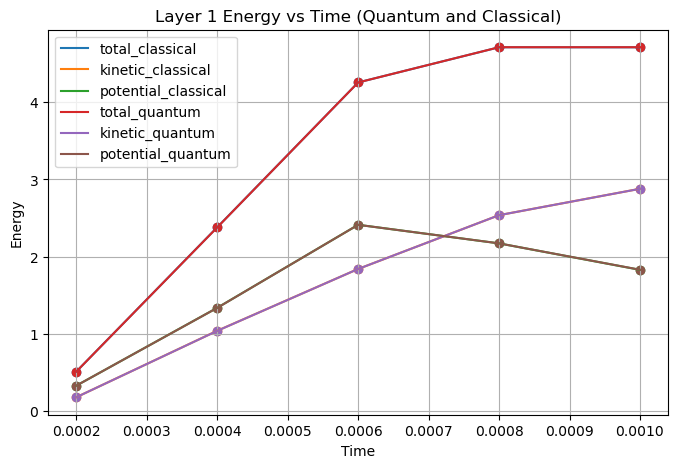

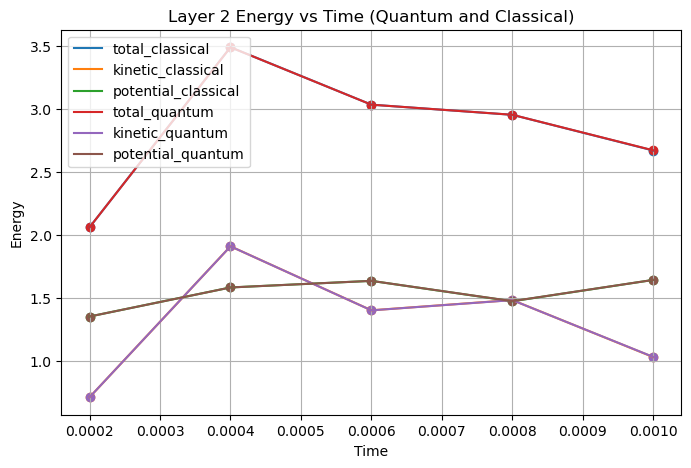

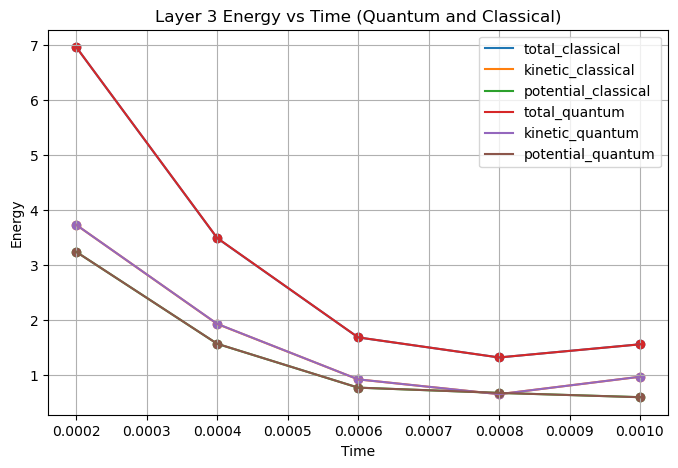

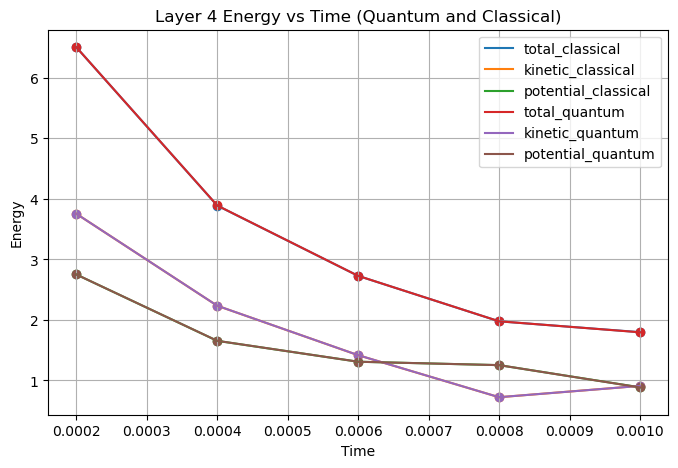

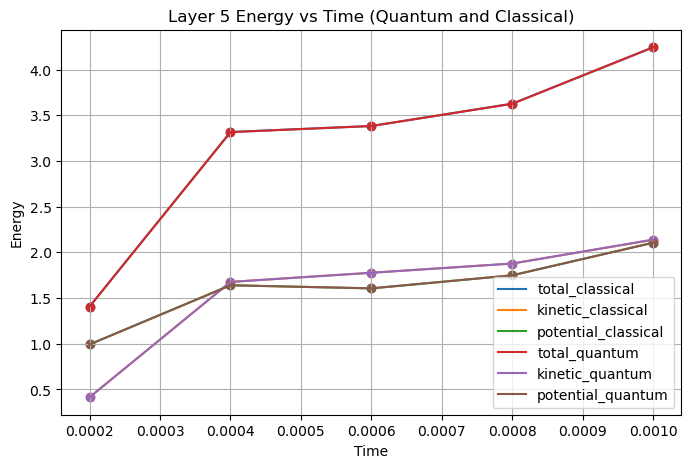

In [58]:
energy_types, times,layer_names = get_layer_dataframes(data)
energy_types, layers, time_names = get_time_dataframes(data)
plot_layer_energy_time(energy_types,times,layer_names)
        

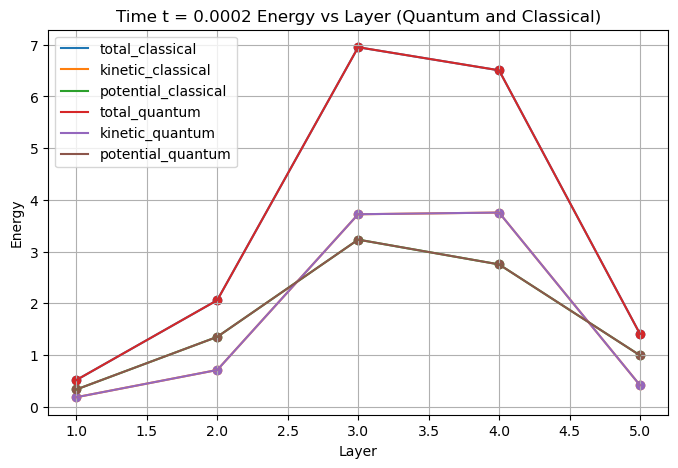

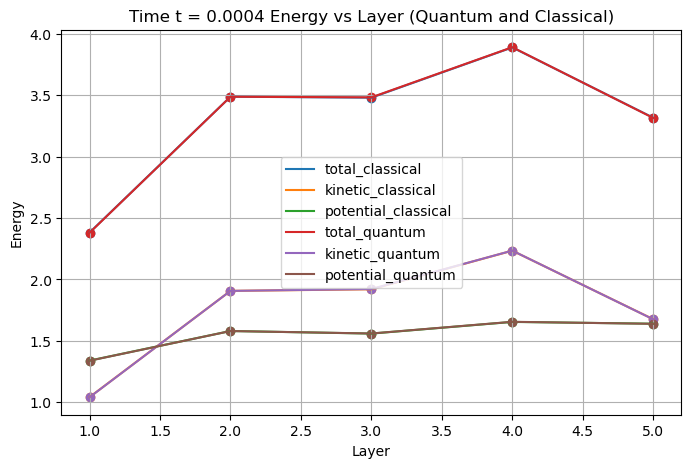

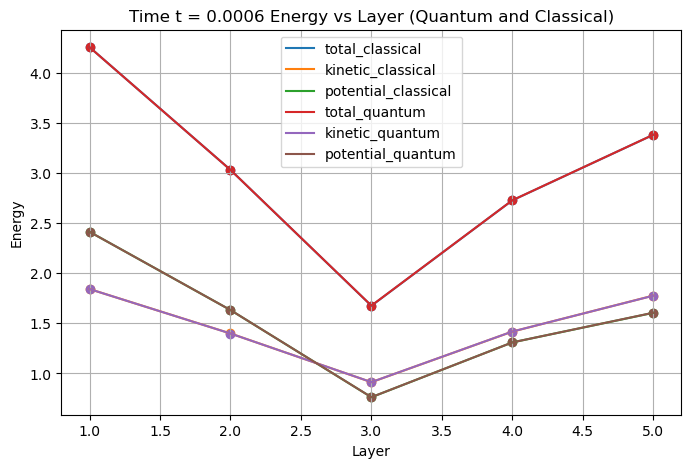

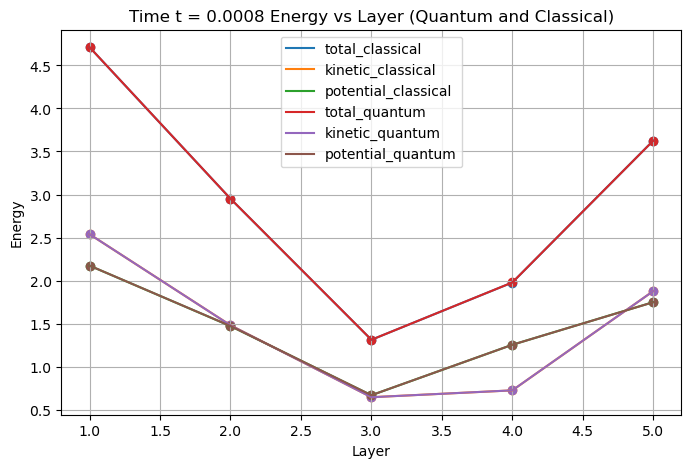

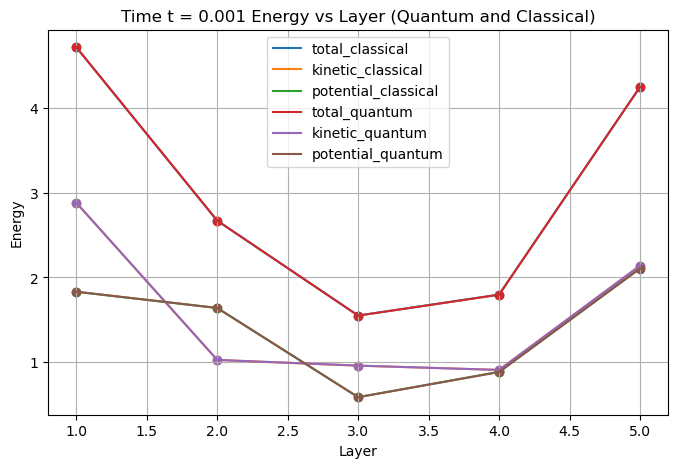

In [60]:
plot_time_energy_layer(energy_types,layers,time_names)